# Sales Performance Analysis

Analysis of 1,246 sales orders (2010–2017) of a company selling 12 product categories in 45 countries.

**Goal:** find out which products, markets, sales channels and periods generate the most profit, and check how long orders take to ship.

**Data:** three tables — `events.csv` (orders), `products.csv` (product categories), `countries.csv` (country names and regions).

**Tools:** Python (pandas, matplotlib, seaborn)

**Contents**
1. Data loading
2. Data cleaning (missing values, data types, duplicates, anomalies)
3. Merging the tables and key metrics
4. Sales by product category
5. Sales by country and region
6. Sales by channel (online vs. offline)
7. Shipment duration
8. Sales over time
9. Weekdays and seasonality
10. Conclusions and recommendations

## 1. Data loading

Upload `dataset.zip` to the Colab session (folder icon on the left → *Upload*) and adjust `ZIP_PATH` if the file name is different.

In [2]:
import os
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
ZIP_PATH = '/content/dataset.zip'
EXTRACT_DIR = '/content/unzipped_data'

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

base_dir = os.path.join(EXTRACT_DIR, '13. Final project')

countries_df = pd.read_csv(os.path.join(base_dir, 'countries.csv'))
products_df = pd.read_csv(os.path.join(base_dir, 'products.csv'))
events_df = pd.read_csv(os.path.join(base_dir, 'events.csv'))

for name, df in [('countries', countries_df), ('products', products_df), ('events', events_df)]:
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

countries: 249 rows, 5 columns
products: 12 rows, 2 columns
events: 1330 rows, 10 columns


In [4]:
display(events_df.head())
display(products_df.head())
display(countries_df.head())

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.00,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,"1,993.00",205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,"4,693.00",668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,"1,171.00",109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,"7,648.00",47.45,31.79


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


## 2. Data cleaning

### 2.1 Missing values

In [5]:
def check_missing_values(df, df_name):
    """Print the number and share of missing values per column."""
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n--- Missing values in {df_name} ---')
    if missing.empty:
        print('No missing values found.')
    else:
        table = pd.DataFrame({
            'Missing count': missing,
            'Missing %': missing / len(df) * 100
        }).sort_values('Missing %', ascending=False)
        print(table)

check_missing_values(countries_df, 'countries_df')
check_missing_values(products_df, 'products_df')
check_missing_values(events_df, 'events_df')


--- Missing values in countries_df ---
            Missing count  Missing %
alpha-2                 1       0.40
region                  1       0.40
sub-region              1       0.40

--- Missing values in products_df ---
No missing values found.

--- Missing values in events_df ---
              Missing count  Missing %
Country Code             82       6.17
Units Sold                2       0.15


Missing values are few, so the affected rows are removed:
- `countries_df`: rows without `alpha-2`, `region` or `sub-region`;
- `events_df`: rows without `Country Code` (cannot be assigned to a country) or `Units Sold` (revenue cannot be calculated).

In [6]:
rows_before = countries_df.shape[0]
countries_df = countries_df.dropna(subset=['alpha-2', 'region', 'sub-region'])
print(f'countries_df: removed {rows_before - countries_df.shape[0]} rows')

rows_before = events_df.shape[0]
events_df = events_df.dropna(subset=['Country Code', 'Units Sold'])
print(f'events_df: removed {rows_before - events_df.shape[0]} rows')

check_missing_values(countries_df, 'countries_df (after cleaning)')
check_missing_values(events_df, 'events_df (after cleaning)')

countries_df: removed 2 rows
events_df: removed 84 rows

--- Missing values in countries_df (after cleaning) ---
No missing values found.

--- Missing values in events_df (after cleaning) ---
No missing values found.


### 2.2 Data types

In [7]:
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])
events_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB


/tmp/ipykernel_3204/641806467.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
/tmp/ipykernel_3204/641806467.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])


### 2.3 Duplicates

In [8]:
for name, df in [('countries_df', countries_df), ('products_df', products_df), ('events_df', events_df)]:
    print(f'{name}: {df.duplicated().sum()} duplicate rows')

countries_df: 0 duplicate rows
products_df: 0 duplicate rows
events_df: 0 duplicate rows


### 2.4 Anomalies and inconsistent values

In [9]:
# Categorical values
print('Regions:')
print(countries_df['region'].value_counts(), '\n')
print('Product categories:')
print(products_df['item_type'].value_counts(), '\n')
print('Sales channels (raw values):')
print(events_df['Sales Channel'].value_counts(), '\n')

# Dates
ship_before_order = (events_df['Ship Date'] < events_df['Order Date']).sum()
print(f'Orders shipped before they were ordered: {ship_before_order}')
print(f"Order dates: {events_df['Order Date'].min():%Y-%m-%d} to {events_df['Order Date'].max():%Y-%m-%d}")

# Numbers
display(events_df[['Units Sold', 'Unit Price', 'Unit Cost']].describe())
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"{col}: {(events_df[col] <= 0).sum()} values <= 0")
print(f"Rows with Unit Cost > Unit Price: {(events_df['Unit Cost'] > events_df['Unit Price']).sum()}")

Regions:
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64 

Product categories:
item_type
Cereal             1
Household          1
Clothes            1
Beverages          1
Office Supplies    1
Fruits             1
Vegetables         1
Baby Food          1
Meat               1
Cosmetics          1
Snacks             1
Personal Care      1
Name: count, dtype: int64 

Sales channels (raw values):
Sales Channel
Online     622
Offline    621
online       3
Name: count, dtype: int64 

Orders shipped before they were ordered: 0
Order dates: 2010-01-01 to 2017-07-22


,Units Sold,Unit Price,Unit Cost
count,"1,246.00","1,246.00","1,246.00"
mean,"4,953.19",264.20,186.31
std,"2,915.83",216.59,175.50
min,2.00,9.33,6.92
25%,"2,349.25",81.73,35.84
50%,"4,980.00",154.06,97.44
75%,"7,477.00",433.37,263.33
max,"9,999.00",668.27,524.96


Units Sold: 0 values <= 0
Unit Price: 0 values <= 0
Unit Cost: 0 values <= 0
Rows with Unit Cost > Unit Price: 0


The sales channel is written in different cases (`Online` / `online`). The values are unified so that both are counted as one channel.

In [10]:
events_df['Sales Channel'] = events_df['Sales Channel'].str.strip().str.capitalize()
print(events_df['Sales Channel'].value_counts())

Sales Channel
Online     625
Offline    621
Name: count, dtype: int64


## 3. Merging the tables and key metrics

In [11]:
merged_df = (
    events_df
    .merge(products_df, left_on='Product ID', right_on='id', how='left')
    .merge(countries_df, left_on='Country Code', right_on='alpha-3', how='left')
    .drop(columns=['id', 'alpha-2', 'alpha-3'])
    .rename(columns={'name': 'Country Name', 'item_type': 'Product Category', 'region': 'Region'})
)

# Check that every order found its product and country
print('Orders without product category:', merged_df['Product Category'].isnull().sum())
print('Orders without country:', merged_df['Country Name'].isnull().sum())

merged_df['Revenue'] = merged_df['Units Sold'] * merged_df['Unit Price']
merged_df['Cost'] = merged_df['Units Sold'] * merged_df['Unit Cost']
merged_df['Profit'] = merged_df['Revenue'] - merged_df['Cost']

print(f'\nMerged table: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns')
display(merged_df.head())

Orders without product category: 0
Orders without country: 0

Merged table: 1246 rows, 17 columns


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Product Category,Country Name,Region,sub-region,Revenue,Cost,Profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Cereal,Norway,Europe,Northern Europe,"133,705.00","76,121.50","57,583.50"
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Cereal,Serbia,Europe,Southern Europe,"409,960.10","233,400.23","176,559.87"
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,"1,171.00",109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,"127,966.88","41,968.64","85,998.24"
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,"7,648.00",47.45,31.79,Beverages,Serbia,Europe,Southern Europe,"362,897.60","243,129.92","119,767.68"
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,"2,220.00",651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,"1,445,686.20","1,165,411.20","280,275.00"


In [12]:
total_revenue = merged_df['Revenue'].sum()
total_profit = merged_df['Profit'].sum()

key_metrics = pd.Series({
    'Orders': merged_df['Order ID'].nunique(),
    'Revenue': total_revenue,
    'Cost': merged_df['Cost'].sum(),
    'Profit': total_profit,
    'Profit margin, %': total_profit / total_revenue * 100,
    'Countries': merged_df['Country Name'].nunique(),
    'Regions': merged_df['Region'].nunique(),
    'Product categories': merged_df['Product Category'].nunique(),
    'Average units per order': merged_df['Units Sold'].mean(),
    'Average profit per order': total_profit / merged_df['Order ID'].nunique(),
})
key_metrics.to_frame('Value')

,Value
Orders,"1,246.00"
Revenue,"1,598,983,761.26"
Cost,"1,125,274,726.20"
Profit,"473,709,035.06"
"Profit margin, %",29.63
Countries,45.00
Regions,2.00
Product categories,12.00
Average units per order,"4,953.19"
Average profit per order,"380,183.82"


## 4. Sales by product category

,Units_Sold,Revenue,Cost,Profit,Margin_%,Profit_share_%
Product Category,,,,,,
Cosmetics,"506,188.00","221,305,393.60","133,294,486.04","88,010,907.56",39.77,18.58
Office Supplies,"581,481.00","378,666,242.01","305,254,265.76","73,411,976.25",19.39,15.50
Household,"417,308.00","278,874,417.16","209,713,962.32","69,160,454.84",24.80,14.60
Baby Food,"524,265.00","133,834,369.20","83,578,326.30","50,256,042.90",37.55,10.61
Clothes,"579,313.00","63,307,324.64","20,762,577.92","42,544,746.72",67.20,8.98
Cereal,"460,266.00","94,676,716.20","53,901,751.26","40,774,964.94",43.07,8.61
Vegetables,"532,510.00","82,038,490.60","48,421,134.30","33,617,356.30",40.98,7.10
Meat,"477,233.00","201,339,830.37","174,042,102.77","27,297,727.60",13.56,5.76
Snacks,"453,621.00","69,213,492.18","44,200,830.24","25,012,661.94",36.14,5.28


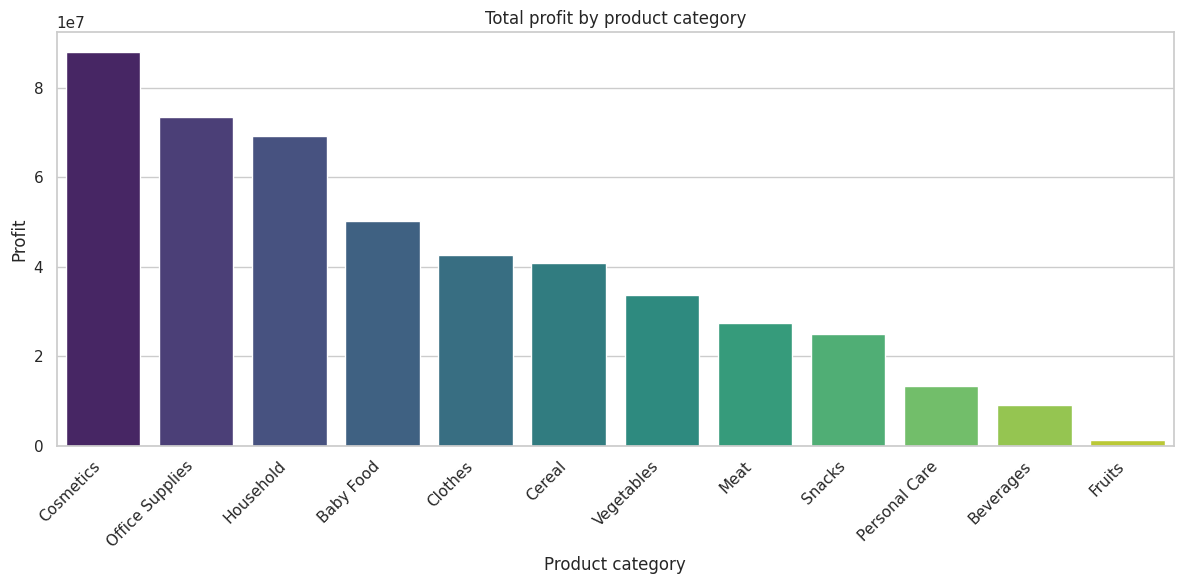

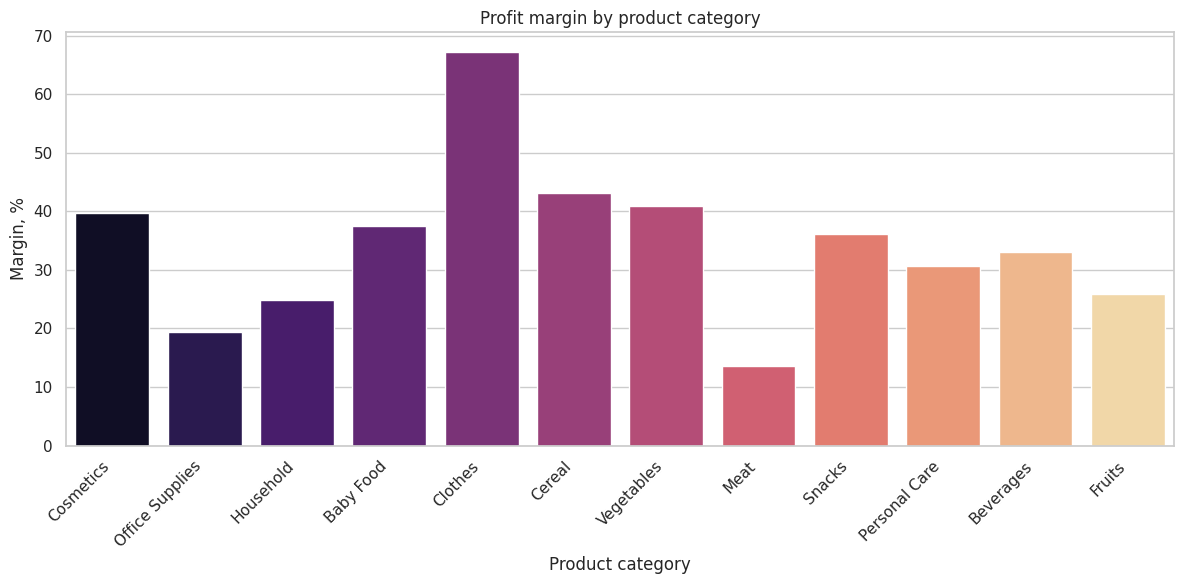

In [13]:
def sales_summary(group_col):
    """Units, revenue, cost, profit and margin per group, sorted by profit."""
    summary = merged_df.groupby(group_col).agg(
        Units_Sold=('Units Sold', 'sum'),
        Revenue=('Revenue', 'sum'),
        Cost=('Cost', 'sum'),
        Profit=('Profit', 'sum'),
    ).sort_values('Profit', ascending=False)
    summary['Margin_%'] = summary['Profit'] / summary['Revenue'] * 100
    summary['Profit_share_%'] = summary['Profit'] / summary['Profit'].sum() * 100
    return summary


def bar_chart(data, x, y, title, xlabel, ylabel, palette='viridis', rotate=True, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.barplot(x=x, y=y, data=data, hue=x, palette=palette, legend=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if rotate:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


sales_by_category = sales_summary('Product Category')
display(sales_by_category)

bar_chart(sales_by_category.reset_index(), 'Product Category', 'Profit',
          'Total profit by product category', 'Product category', 'Profit')
bar_chart(sales_by_category.reset_index(), 'Product Category', 'Margin_%',
          'Profit margin by product category', 'Product category', 'Margin, %', palette='magma')

## 5. Sales by country and region

,Units_Sold,Revenue,Cost,Profit,Margin_%,Profit_share_%
Country Name,,,,,,
Andorra,"185,686.00","47,756,693.17","32,346,656.54","15,410,036.63",32.27,3.25
Ukraine,"164,577.00","53,252,317.54","38,447,391.80","14,804,925.74",27.80,3.13
Malta,"173,641.00","47,145,320.81","32,535,192.93","14,610,127.88",30.99,3.08
San Marino,"192,228.00","47,883,708.48","34,090,715.67","13,792,992.81",28.81,2.91
Hungary,"152,242.00","42,408,249.12","28,622,018.09","13,786,231.03",32.51,2.91
Macedonia,"203,078.00","49,222,085.25","35,537,985.30","13,684,099.95",27.80,2.89
Czech Republic,"142,446.00","53,543,932.14","39,908,338.36","13,635,593.78",25.47,2.88
Russia,"165,954.00","46,051,659.81","32,783,977.17","13,267,682.64",28.81,2.80
Bosnia and Herzegovina,"153,545.00","50,117,508.49","36,859,905.72","13,257,602.77",26.45,2.80


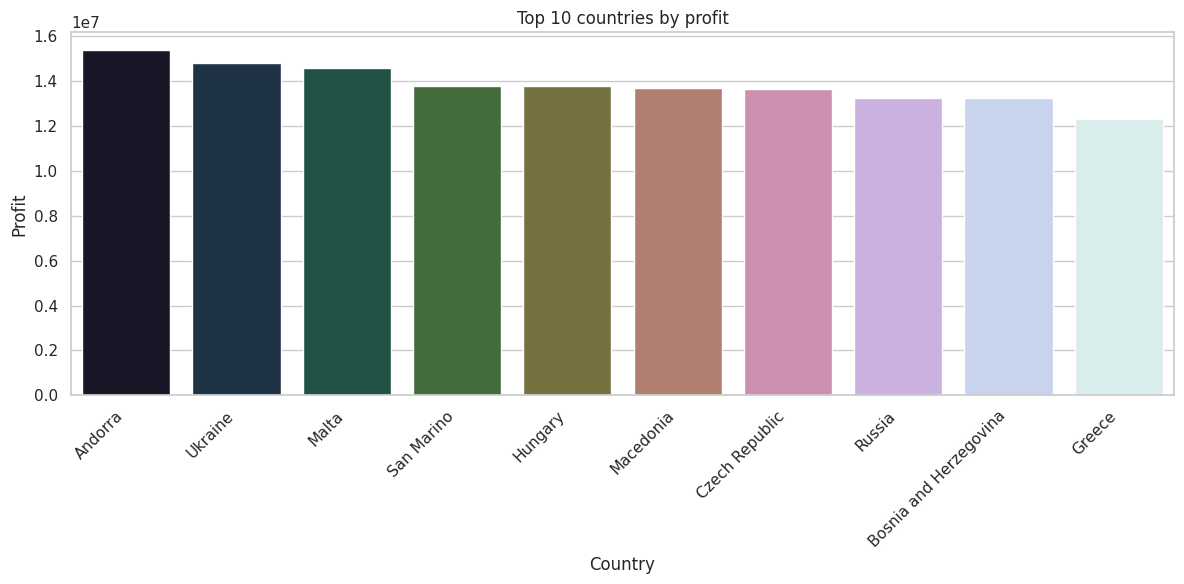

,Units_Sold,Revenue,Cost,Profit,Margin_%,Profit_share_%
Region,,,,,,
Europe,"5,761,244.00","1,505,652,873.89","1,057,096,091.78","448,556,782.11",29.79,94.69
Asia,"410,427.00","93,330,887.37","68,178,634.42","25,152,252.95",26.95,5.31


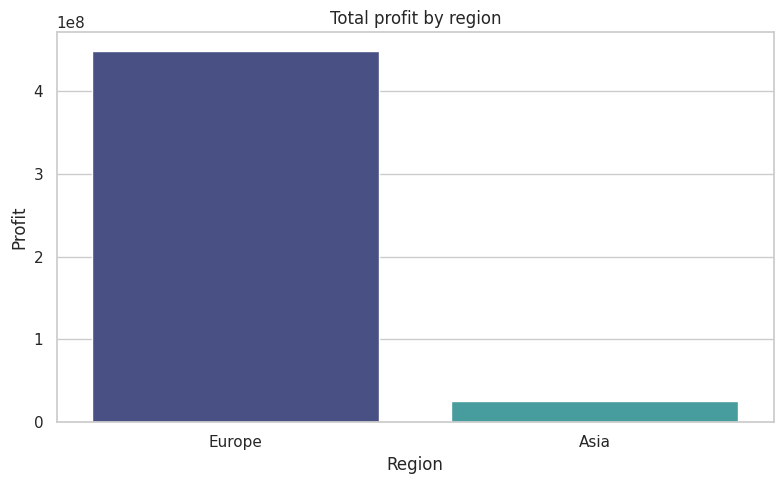

In [14]:
sales_by_country = sales_summary('Country Name')
display(sales_by_country.head(10))

bar_chart(sales_by_country.head(10).reset_index(), 'Country Name', 'Profit',
          'Top 10 countries by profit', 'Country', 'Profit', palette='cubehelix')

sales_by_region = sales_summary('Region')
display(sales_by_region)

bar_chart(sales_by_region.reset_index(), 'Region', 'Profit',
          'Total profit by region', 'Region', 'Profit', palette='mako', rotate=False, figsize=(8, 5))

## 6. Sales by channel (online vs. offline)

,Units_Sold,Revenue,Cost,Profit,Margin_%,Profit_share_%,Orders,Avg_units_per_order,Avg_profit_per_order
Sales Channel,,,,,,,,,
Offline,"3,113,412.00","810,030,465.24","571,519,137.83","238,511,327.41",29.44,50.35,621,"5,013.55","384,076.21"
Online,"3,058,259.00","788,953,296.02","553,755,588.37","235,197,707.65",29.81,49.65,625,"4,893.21","376,316.33"


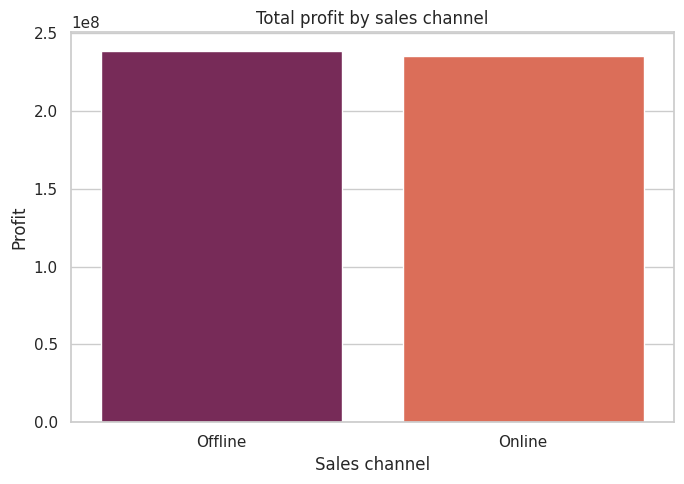

In [15]:
sales_by_channel = sales_summary('Sales Channel')
sales_by_channel['Orders'] = merged_df.groupby('Sales Channel')['Order ID'].nunique()
sales_by_channel['Avg_units_per_order'] = merged_df.groupby('Sales Channel')['Units Sold'].mean()
sales_by_channel['Avg_profit_per_order'] = sales_by_channel['Profit'] / sales_by_channel['Orders']
display(sales_by_channel)

bar_chart(sales_by_channel.reset_index(), 'Sales Channel', 'Profit',
          'Total profit by sales channel', 'Sales channel', 'Profit',
          palette='rocket', rotate=False, figsize=(7, 5))

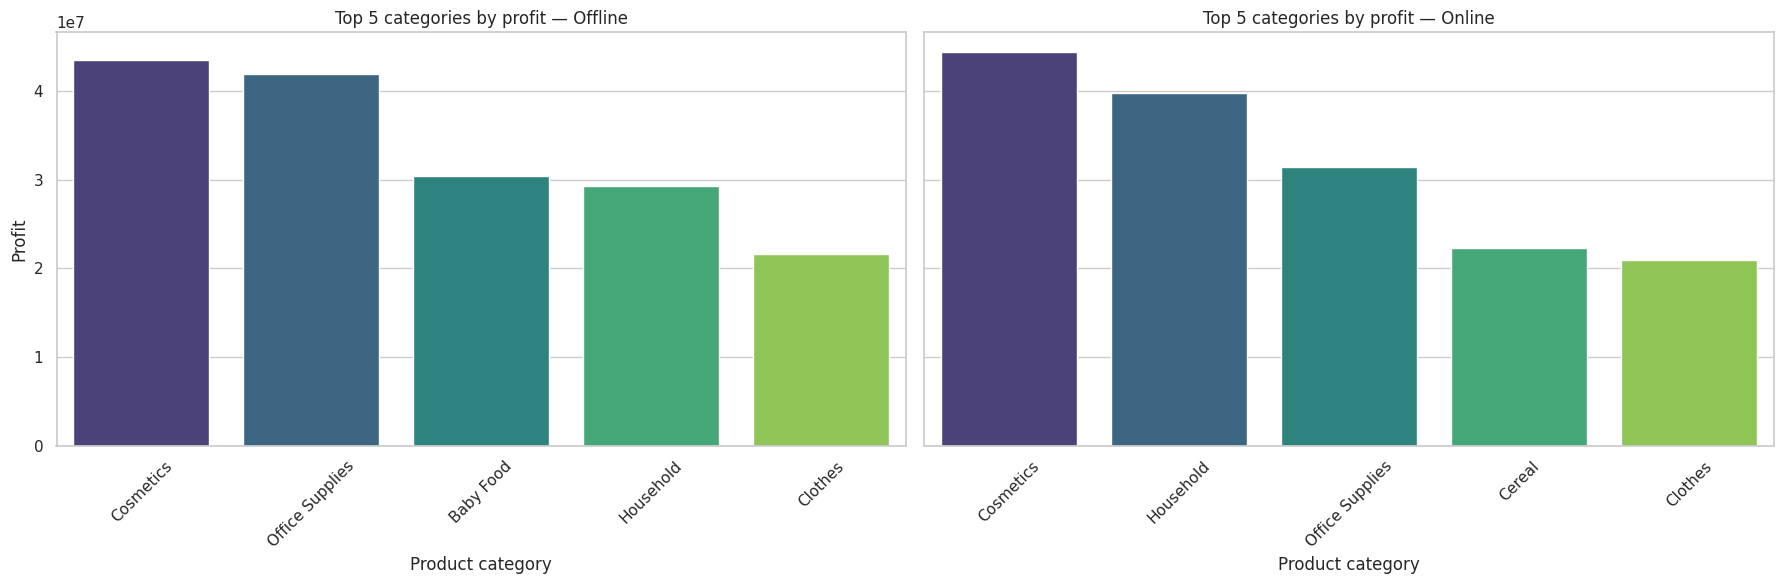

In [16]:
# Top 5 product categories by profit in each channel
channels = sorted(merged_df['Sales Channel'].unique())
fig, axes = plt.subplots(1, len(channels), figsize=(18, 6), sharey=True)

for ax, channel in zip(axes, channels):
    top5 = (merged_df[merged_df['Sales Channel'] == channel]
            .groupby('Product Category')['Profit'].sum()
            .nlargest(5).reset_index())
    sns.barplot(x='Product Category', y='Profit', data=top5, hue='Product Category',
                palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Top 5 categories by profit — {channel}')
    ax.set_xlabel('Product category')
    ax.set_ylabel('Profit')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Shipment duration

Time between order date and ship date, in days.

,"Shipment duration, days"
count,"1,246.00"
mean,24.88
std,14.62
min,0.00
25%,12.00
50%,25.00
75%,37.00
max,50.00


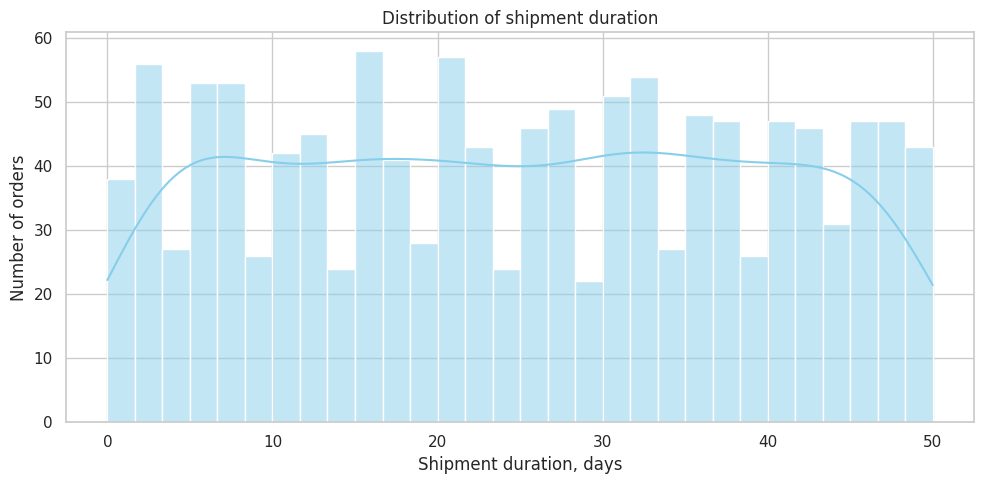

In [17]:
merged_df['Shipment_Duration'] = (merged_df['Ship Date'] - merged_df['Order Date']).dt.days
display(merged_df['Shipment_Duration'].describe().to_frame('Shipment duration, days'))

plt.figure(figsize=(10, 5))
sns.histplot(merged_df['Shipment_Duration'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of shipment duration')
plt.xlabel('Shipment duration, days')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

,Product Category,Shipment_Duration
0,Office Supplies,27.28
1,Cereal,27.20
2,Baby Food,26.65
3,Cosmetics,25.88
4,Meat,25.74
5,Snacks,25.26
6,Fruits,24.48
7,Vegetables,24.44
8,Beverages,23.95
9,Household,23.57


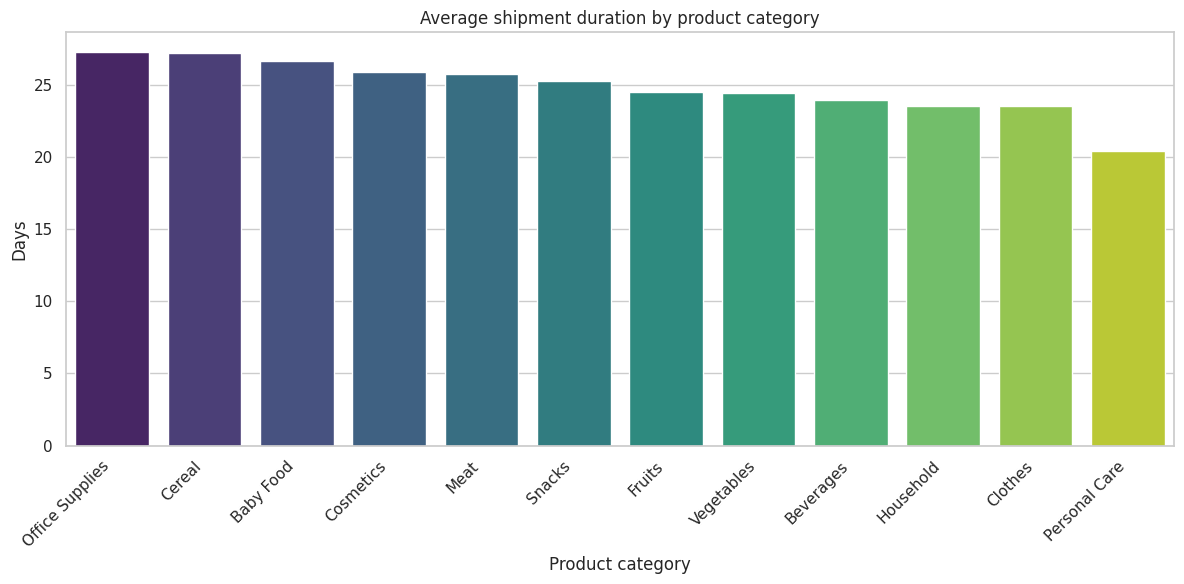

,Country Name,Shipment_Duration
0,Hungary,32.64
1,Georgia,29.70
2,Austria,28.50
3,Slovakia,28.47
4,Luxembourg,27.75
5,Lithuania,27.56
6,Poland,27.46
7,Russia,27.38
8,Monaco,26.85
9,Bulgaria,26.80


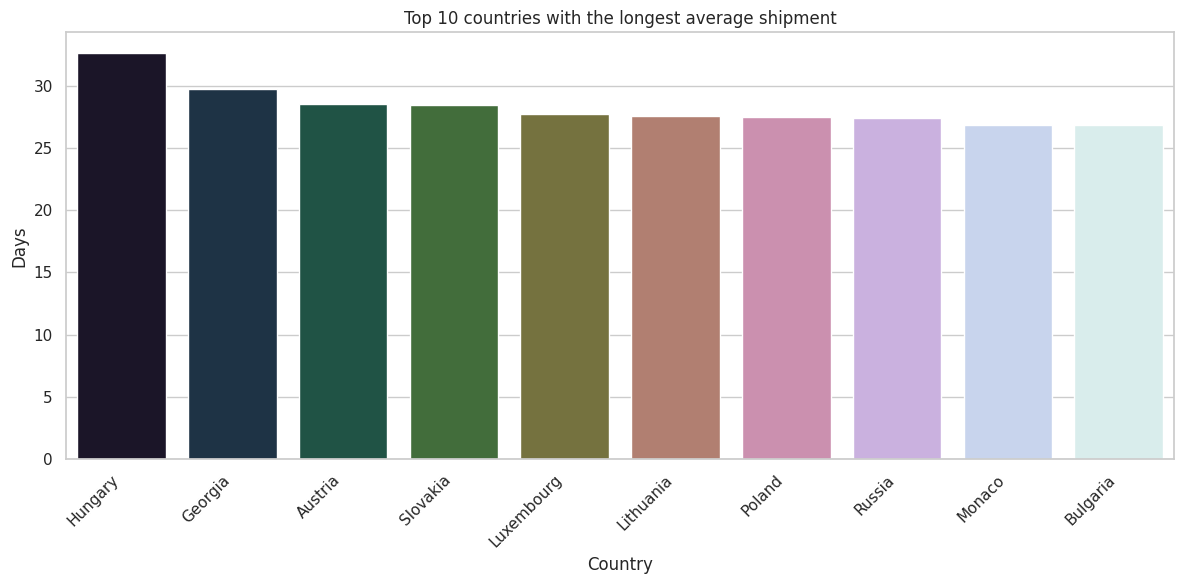

,Average days
Region,
Asia,26.09
Europe,24.79


In [18]:
duration_by_category = (merged_df.groupby('Product Category')['Shipment_Duration']
                        .mean().sort_values(ascending=False).reset_index())
display(duration_by_category)
bar_chart(duration_by_category, 'Product Category', 'Shipment_Duration',
          'Average shipment duration by product category', 'Product category', 'Days')

duration_by_country = (merged_df.groupby('Country Name')['Shipment_Duration']
                       .mean().sort_values(ascending=False).head(10).reset_index())
display(duration_by_country)
bar_chart(duration_by_country, 'Country Name', 'Shipment_Duration',
          'Top 10 countries with the longest average shipment', 'Country', 'Days', palette='cubehelix')

display(merged_df.groupby('Region')['Shipment_Duration'].mean().to_frame('Average days'))

### Is profit related to shipment duration?

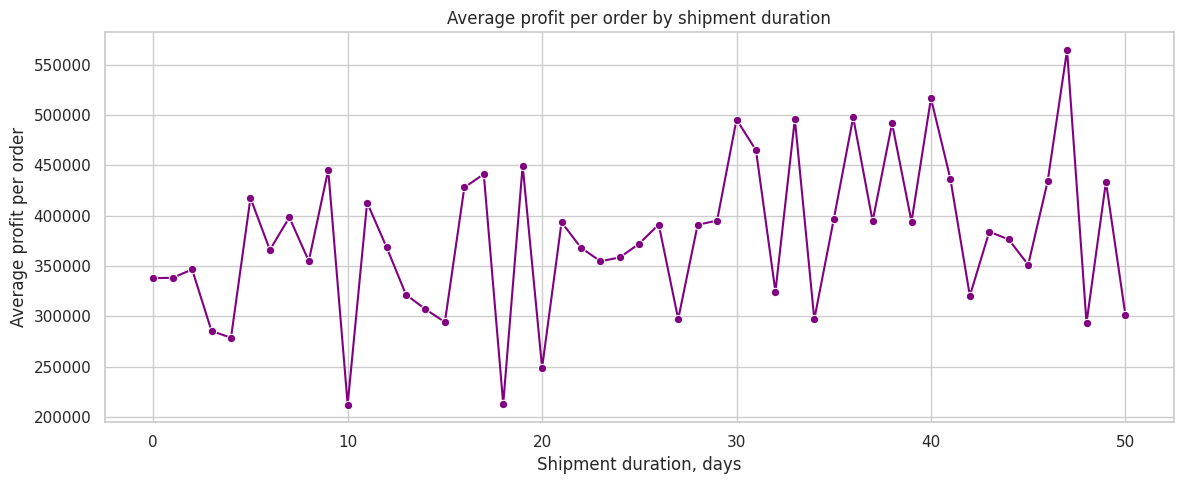

Correlation between shipment duration and profit per order: r = 0.061


In [19]:
profit_by_duration = merged_df.groupby('Shipment_Duration')['Profit'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x='Shipment_Duration', y='Profit', data=profit_by_duration, marker='o', color='purple')
plt.title('Average profit per order by shipment duration')
plt.xlabel('Shipment duration, days')
plt.ylabel('Average profit per order')
plt.tight_layout()
plt.show()

corr = merged_df['Shipment_Duration'].corr(merged_df['Profit'])
print(f'Correlation between shipment duration and profit per order: r = {corr:.3f}')

## 8. Sales over time

,Profit,Orders
Order Date,,
2010,"59,817,992.71",159
2011,"64,367,010.94",163
2012,"83,070,056.18",187
2013,"51,221,929.68",150
2014,"65,979,379.16",172
2015,"58,226,509.54",150
2016,"55,100,085.19",165
2017,"35,926,071.66",100


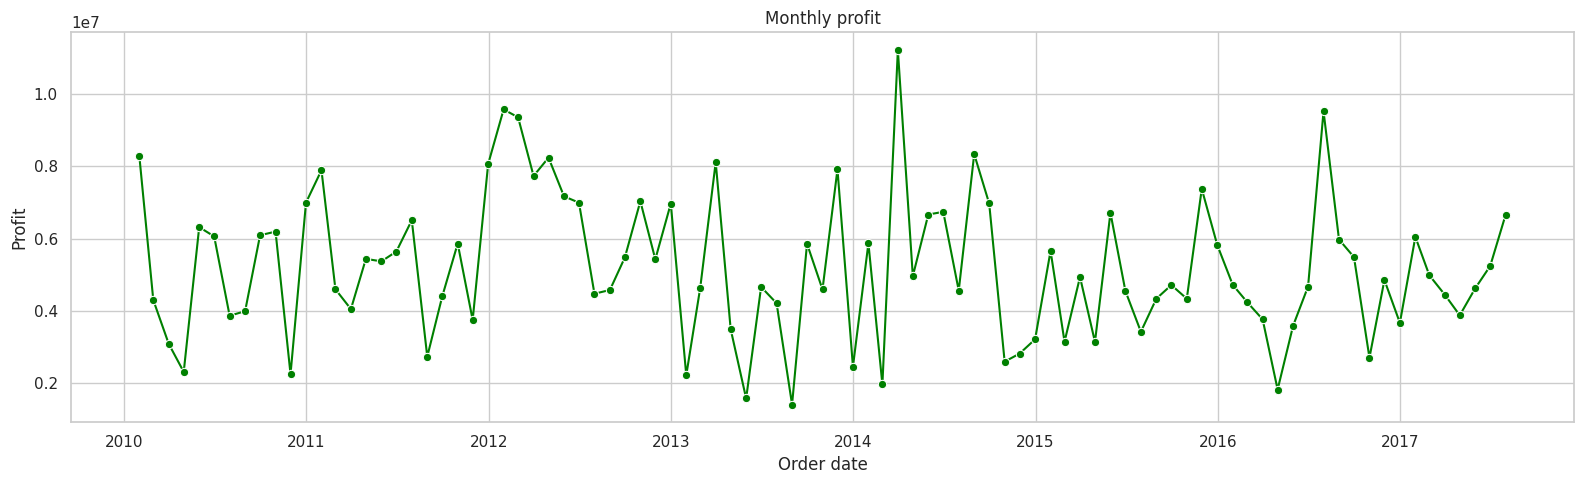

In [20]:
time_df = merged_df.set_index('Order Date').sort_index()

sales_monthly = time_df.resample('ME').agg(Profit=('Profit', 'sum'), Units_Sold=('Units Sold', 'sum'))
sales_yearly = time_df.resample('YE').agg(Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
sales_yearly.index = sales_yearly.index.year
display(sales_yearly)

plt.figure(figsize=(16, 5))
sns.lineplot(x=sales_monthly.index, y=sales_monthly['Profit'], marker='o', color='green')
plt.title('Monthly profit')
plt.xlabel('Order date')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

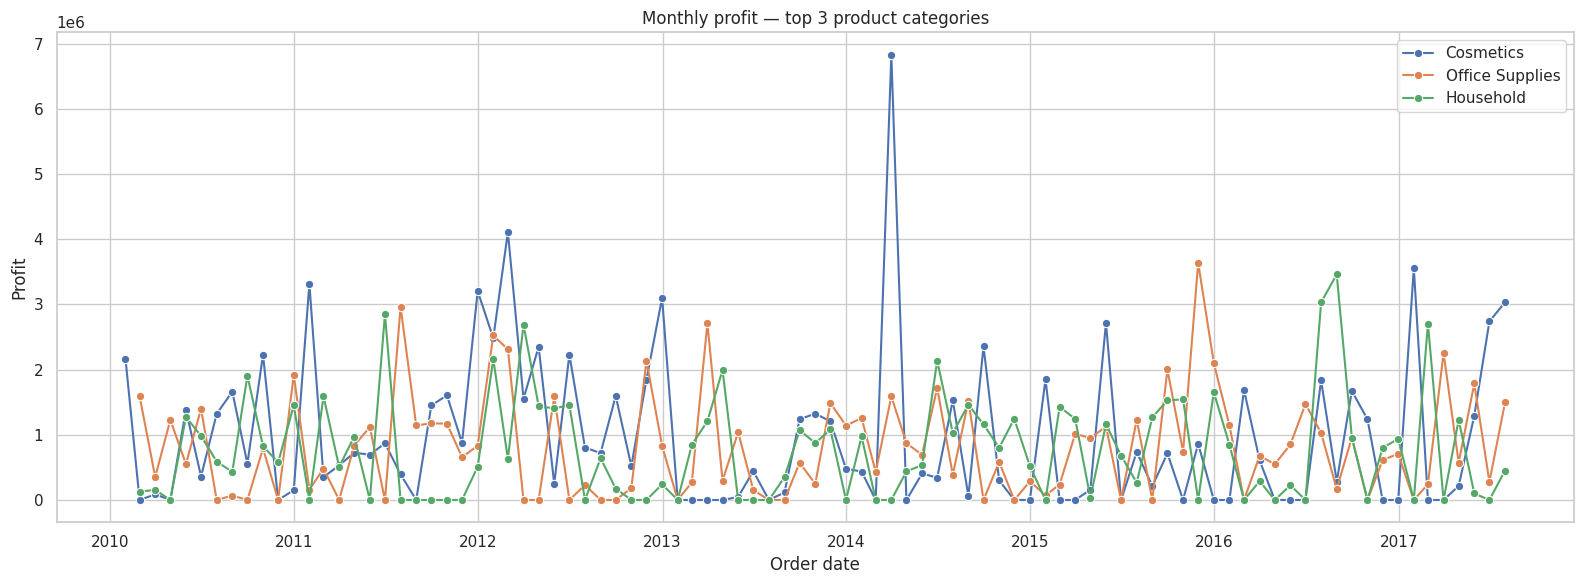

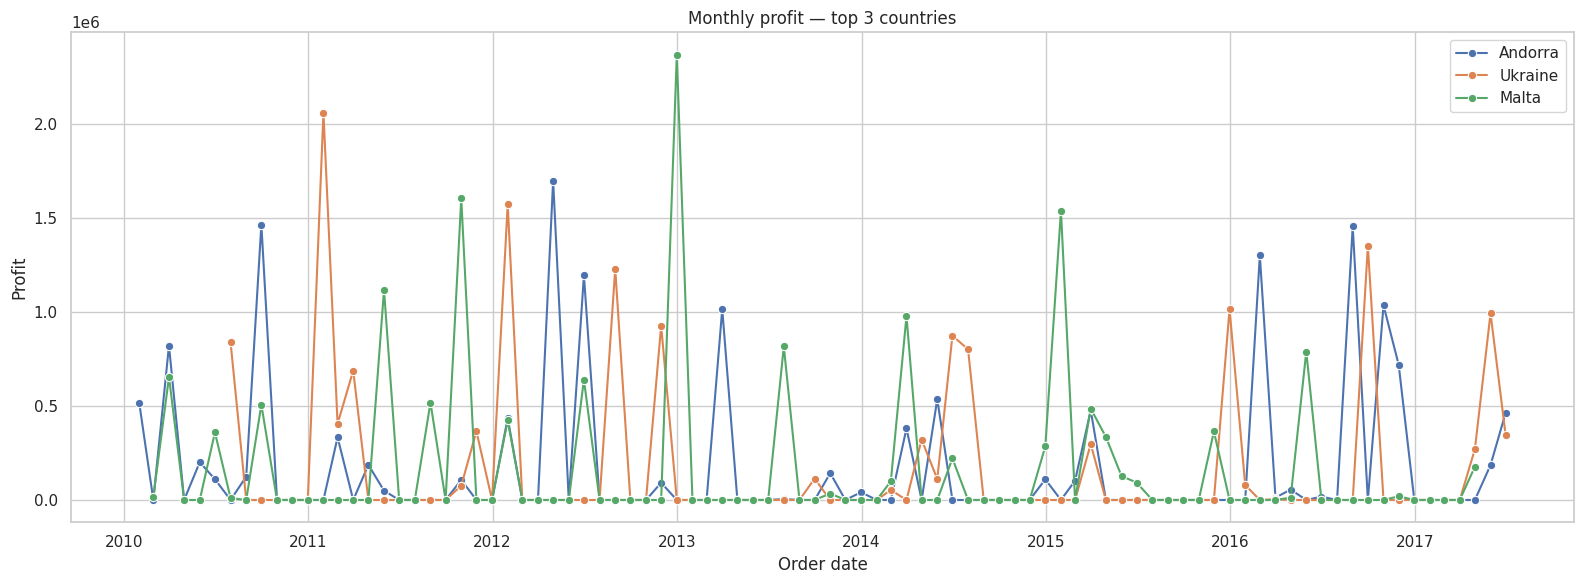

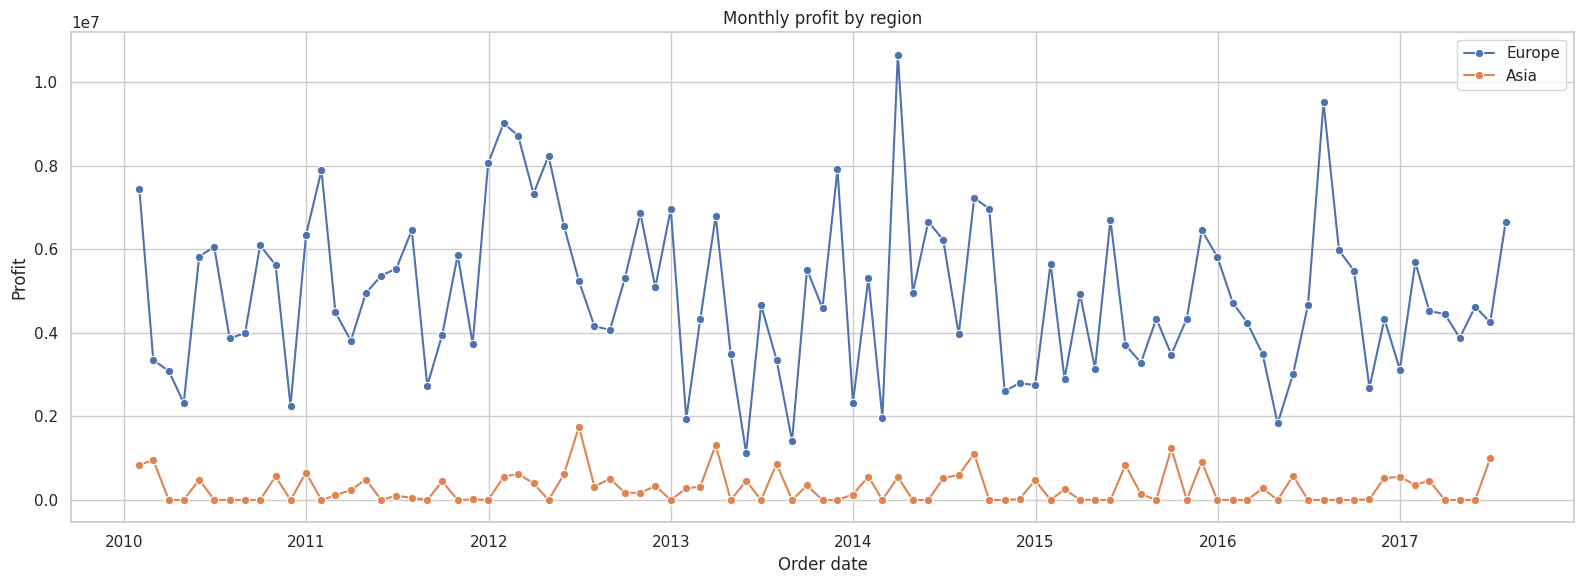

In [21]:
def monthly_profit_by(group_col, values, title):
    plt.figure(figsize=(16, 6))
    for value in values:
        series = time_df[time_df[group_col] == value].resample('ME')['Profit'].sum()
        sns.lineplot(x=series.index, y=series.values, label=value, marker='o')
    plt.title(title)
    plt.xlabel('Order date')
    plt.ylabel('Profit')
    plt.legend()
    plt.tight_layout()
    plt.show()

top_3_categories = sales_by_category.head(3).index
top_3_countries = sales_by_country.head(3).index

monthly_profit_by('Product Category', top_3_categories, 'Monthly profit — top 3 product categories')
monthly_profit_by('Country Name', top_3_countries, 'Monthly profit — top 3 countries')
monthly_profit_by('Region', merged_df['Region'].unique(), 'Monthly profit by region')

## 9. Weekdays and seasonality

,Orders,Units_Sold,Profit
Day_of_Week,,,
Monday,184,"933,677.00","72,156,995.30"
Tuesday,174,"833,975.00","63,512,866.99"
Wednesday,182,"839,870.00","67,768,122.43"
Thursday,158,"818,022.00","60,108,355.32"
Friday,163,"787,802.00","73,323,427.18"
Saturday,191,"970,549.00","68,743,185.28"
Sunday,194,"987,776.00","68,096,082.56"


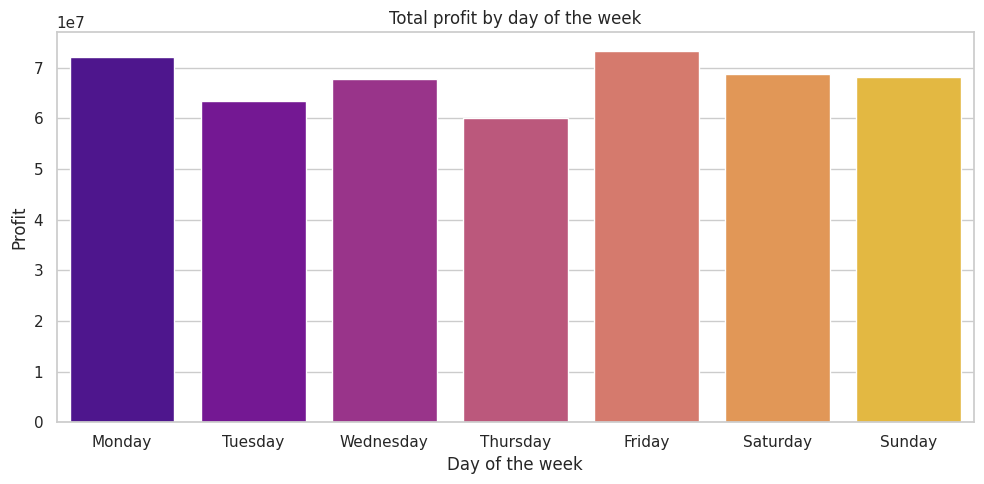

In [22]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
merged_df['Day_of_Week'] = pd.Categorical(merged_df['Order Date'].dt.day_name(),
                                          categories=day_order, ordered=True)

sales_by_weekday = merged_df.groupby('Day_of_Week', observed=False).agg(
    Orders=('Order ID', 'nunique'),
    Units_Sold=('Units Sold', 'sum'),
    Profit=('Profit', 'sum'),
)
display(sales_by_weekday)

bar_chart(sales_by_weekday.reset_index(), 'Day_of_Week', 'Profit',
          'Total profit by day of the week', 'Day of the week', 'Profit',
          palette='plasma', rotate=False, figsize=(10, 5))

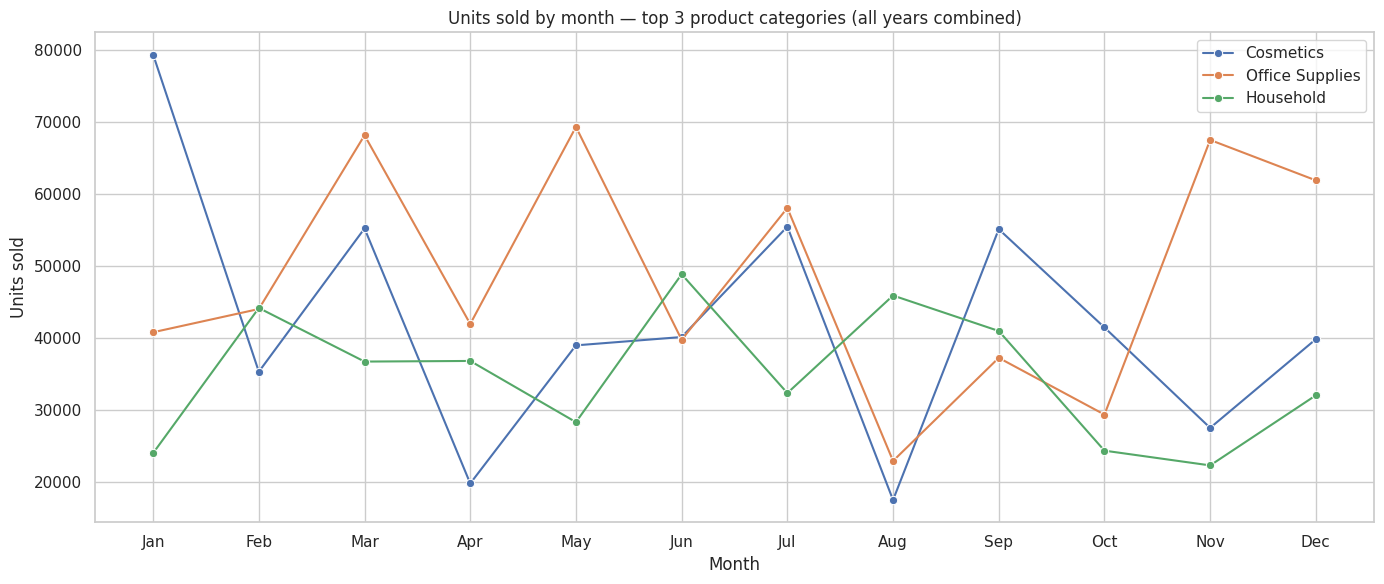

In [23]:
merged_df['Month'] = merged_df['Order Date'].dt.month
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
for category in top_3_categories:
    seasonal = merged_df[merged_df['Product Category'] == category].groupby('Month')['Units Sold'].sum()
    sns.lineplot(x=seasonal.index, y=seasonal.values, label=category, marker='o')

plt.title('Units sold by month — top 3 product categories (all years combined)')
plt.xlabel('Month')
plt.ylabel('Units sold')
plt.xticks(range(1, 13), month_labels)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Conclusions and recommendations

### Data quality
- 84 of 1,330 orders (6.3%) had no country code or number of units and were removed; 2 countries without region data were removed.
- Sales channel values were written inconsistently (`Online` / `online`) and were unified.
- No duplicates, no orders shipped before they were ordered, no prices below cost.

### Key metrics
1,246 orders, revenue of about **1.60 billion**, profit of about **474 million** (margin ≈ 30%), 45 countries, 12 product categories, average profit per order ≈ 380,000.

### Findings
1. **Products.** Cosmetics (88M), Office Supplies (73M) and Household (69M) bring the most profit. Office Supplies and Meat have high revenue but the lowest margins (≈19% and ≈14%), while Clothes has a small revenue but the highest margin (≈67%). Fruits and Beverages bring the least profit.
2. **Geography.** Europe generates about **95% of profit**, Asia the rest. The most profitable countries are Andorra, Ukraine and Malta, but the top-10 countries are very close to each other (≈12–15M each), so no single market dominates.
3. **Channels.** Online and offline are almost equal: offline brings 50.3% of profit, online 49.7%, with similar profit per order. The channel is not a key driver of profit.
4. **Shipping.** Orders take on average about 25 days to ship (Personal Care ≈ 20 days, Office Supplies and Cereal ≈ 27 days; Hungary has the longest average — ≈ 33 days). There is **no clear relationship** between shipment duration and profit.
5. **Weekdays.** Friday and Monday are the most profitable days, Thursday the least (about 18% lower than Friday).
6. **Over time.** Monthly profit fluctuates strongly, and the top categories and countries have different monthly patterns, which points to category-specific seasonality.

### Recommendations
- Focus marketing and assortment on high-profit and high-margin categories (Cosmetics, Household, Clothes); review pricing or costs for Office Supplies and Meat (high revenue, low margin) and low-profit categories (Fruits, Beverages).
- Keep investing in both channels equally — neither clearly outperforms the other.
- Shorten shipment times for the slowest categories and countries to improve customer experience, even though no direct effect on profit was found.
- Plan promotions for weaker days (Tuesday–Thursday) and use seasonal patterns per category for stock planning.

### Limitations
The data contains only one order per order ID, no customer information and no marketing costs, so customer behaviour and channel ROI cannot be analysed. Asia is represented by few countries, so regional comparisons should be read with caution.